# **MODEL TRAINING WITH ORIGINAL DATA NOTEBOOK**

## **0. Library import**

This section imports the libraries and modules needed for building, training, and evaluating machine learning models. Including:
- `pandas` for data processing,
- `sklearn` for data splitting and normalization,
- custom model classes such as SGD, Logistic Regression, Random Forest, Naive Bayes,...
Restructuring functions/files ensures modularity and ease of reuse when upgrading the pipeline in subsequent experiments.

In [1]:
import os
import sys
# Add the root path into the python path
root_path = os.path.abspath(os.path.join(".."))
if not root_path in sys.path:
    sys.path.insert(0, root_path)

In [2]:
import pandas as pd
import warnings

warnings.filterwarnings(action="ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from src.config import BRFSS_CLEANED_FILE_PATH, LOG_DIR, TRAIN_SIZE, RANDOM_STATE, N_JOBS, \
    SGD_ALPHA, SGD_MAX_ITER, SGD_LOSS, SGD_PENALTY, SGD_LEARNING_RATE, \
    LR_C, LR_PENALTY, LR_CLASS_WEIGHT, LR_VERBOSE, LR_MAX_ITER, LR_SOLVER, \
    RF_N_ESTIMATORS, RF_MAX_DEPTH, RF_MIN_SAMPLES_SPLIT, RF_MIN_SAMPLES_LEAF, RF_CLASS_WEIGHT, \
    NB_ALPHA, NB_TYPE, NB_BINARIZE, NB_VAR_SMOOTHING, \
    XGB_N_ESTIMATORS, XGB_MAX_DEPTH, XGB_LEARNING_RATE, XGB_SUBSAMPLE, XGB_COLSAMPLE_BY_TREE, \
    LGBM_N_ESTIMATORS, LGBM_MAX_DEPTH, LGBM_LEARNING_RATE, LGBM_NUM_LEAVES, LGBM_SUBSAMPLE, LGBM_COLSAMPLE_BY_TREE
from src.evaluate import compare_models
from src.visualization import plot_roc_auc, plot_compare_models
from src.models import (
    DiabetesSGDClassifier, DiabetesLogisticRegression, 
    DiabetesRandomForest, DiabetesNaiveBayes,
    DiabetesXGBoostClassifier, DiabetesLightGBMClassifier
)

## **1. Load dataset**

The BRFSS dataset has been cleaned from the previous pipeline, including 78,7602 rows, 21 columns. This is the original dataset before going through Feature Engineering and has been processed for missing data issues, ready for the model building steps.

In [3]:
# Read dataset
df = pd.read_csv(filepath_or_buffer=BRFSS_CLEANED_FILE_PATH)
df.shape

(787602, 21)

## **2. Split train and test data**

This part performs the data splitting into training and testing sets. We split the features (X) and target variable (y - Diabetes column) from the original dataset. Then use the parameter `stratify=y` to ensure the ratio of classes in the training and testing sets is the same, avoiding data imbalance. `train_test_split`

The data-splitting results show:

- X_train shape: (629,281, 20)—training set with about 80% of the data
- X_test shape: (158,321, 20)—testing set with about 20% of the data
- y_train and y_test have the same number as X

This ensures that we have enough data to train complex models and still have a reliable test set to evaluate.

In [4]:
# Separate features (X) and target variable (y) for model training
X = df.drop("Diabetes", axis=1)
y = df["Diabetes"]

In [5]:
# Apply stratified train-test split to maintain class distributio
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (630081, 20)
X_test shape: (157521, 20)
y_train shape: (630081,)
y_test shape: (157521,)


## **3. Data normalization**

This section normalizes the data using MinMaxScaler to bring all features to the same value range [0,1]. This is important because:

The features in the dataset have different scales (BMI from 12 to 99, Age from 1 to 13, binary features 0–1, etc.). Without normalization, the large features will dominate the learning process of algorithms such as SGD and Logistic Regression.

The MinMaxScaler is fitted on the training set and then transforms both the training and testing sets. This ensures that there is no data leakage from the test set into the normalization process.

In [6]:
# Apply MinMax normalization to scale features to [0,1] ranges
min_max_scaler = MinMaxScaler()
X_train_normalized = min_max_scaler.fit_transform(X=X_train)
X_test_normalized = min_max_scaler.transform(X=X_test)

In [7]:
X_train_normalized[0]

array([0.        , 1.        , 1.        , 0.1954023 , 1.        ,
       0.        , 0.        , 1.        , 0.        , 0.01010101,
       0.        , 0.5       , 0.1       , 0.        , 0.        ,
       0.        , 0.66666667, 1.        , 0.7       , 0.        ])

## **3. Train models**

This section builds and evaluates four different machine learning models on the same dataset to compare their performance.

### **3.1 SGD Classifier**

Stochastic Gradient Descent Classifier is an optimization algorithm suitable for large datasets such as BRFSS with nearly 800K records. The model is initialized with hyperparameters from the config file and logged into . `../logs/2_sgd_classifier_with_original_data.log`
From the training and evaluation process, SGD Classifier shows:

- Ability to handle large datasets well with fast training speed
- Cross-validation results show the stability of the model through different folds
- ROC-AUC plot helps evaluate the ability to distinguish between classes, especially important for multi-class problems such as diabetes

In [8]:
# Initialize and configure SGD model
sgd_model = DiabetesSGDClassifier(
    loss=SGD_LOSS,
    penalty=SGD_PENALTY,
    alpha=SGD_ALPHA,
    max_iter=SGD_MAX_ITER,
    random_state=RANDOM_STATE,
    learning_rate=SGD_LEARNING_RATE,
    n_jobs=N_JOBS,
    log_file=f"{LOG_DIR}/2_sgd_classifier_with_original_data.log",
)

2025-09-16 21:04:59,357 - [src.models] - INFO - DiabetesSGDClassifier initialized with parameters:
2025-09-16 21:04:59,358 - [src.models] - INFO -   loss: log_loss
2025-09-16 21:04:59,359 - [src.models] - INFO -   penalty: l2
2025-09-16 21:04:59,360 - [src.models] - INFO -   alpha: 0.0001
2025-09-16 21:04:59,360 - [src.models] - INFO -   learning_rate: constant
2025-09-16 21:04:59,361 - [src.models] - INFO -   eta0: 0.01
2025-09-16 21:04:59,362 - [src.models] - INFO -   max_iter: 1000
2025-09-16 21:04:59,363 - [src.models] - INFO -   random_state: 42


In [9]:
# Get the model information
sgd_model.get_model_info()

{'loss': 'log_loss',
 'penalty': 'l2',
 'alpha': 0.0001,
 'learning_rate': 'constant',
 'eta0': 0.01,
 'max_iter': 1000,
 'random_state': 42,
 'model_path': None,
 'is_fitted': False}

In [10]:
# Train the SGD model on normalized training data
sgd_model.train(X=X_train_normalized, y=y_train)

2025-09-16 21:04:59,386 - [src.models] - INFO - Starting SGD Classifier model training...
2025-09-16 21:05:00,932 - [src.models] - INFO - Model training completed. Training samples: 630081
2025-09-16 21:05:00,933 - [src.models] - INFO - Number of iterations: 7


In [11]:
# Generate predictions
sgd_y_pred = sgd_model.predict(X=X_test_normalized)

2025-09-16 21:05:00,957 - [src.models] - INFO - Predictions made for 157521 samples


In [12]:
# Display the first 10 predictions to verify the output format
sgd_y_pred[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [13]:
# Evaluate SGDClassifier model
sgd_model_eval_results = sgd_model.evaluate(y_true=y_test, y_pred=sgd_y_pred)

2025-09-16 21:05:01,072 - [src.models] - INFO - Model Evaluation Results:
2025-09-16 21:05:01,073 - [src.models] - INFO - Accuracy: 0.8400
2025-09-16 21:05:01,074 - [src.models] - INFO - Precision: 0.4605
2025-09-16 21:05:01,075 - [src.models] - INFO - Recall: 0.3921
2025-09-16 21:05:01,076 - [src.models] - INFO - F1-Score: 0.4023
2025-09-16 21:05:01,131 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91    131574
         1.0       0.00      0.00      0.00      3393
         2.0       0.52      0.21      0.30     22554

    accuracy                           0.84    157521
   macro avg       0.46      0.39      0.40    157521
weighted avg       0.79      0.84      0.80    157521

2025-09-16 21:05:01,178 - [src.models] - INFO - Confusion Matrix:
[[127671      0   3903]
 [  3048      0    345]
 [ 17906      0   4648]]


In [14]:
# Display model performance metrics
sgd_model_eval_results

{'accuracy': 0.8400086337694657,
 'precision': 0.4604987707058911,
 'recall': 0.3921397542623332,
 'f1_score': 0.40228944500650554}

In [15]:
# Predict class probabilities
sgd_class_probabilities = sgd_model.predict_proba(X=X_test_normalized)

2025-09-16 21:05:01,223 - [src.models] - INFO - Probabilities predicted for 157521 samples


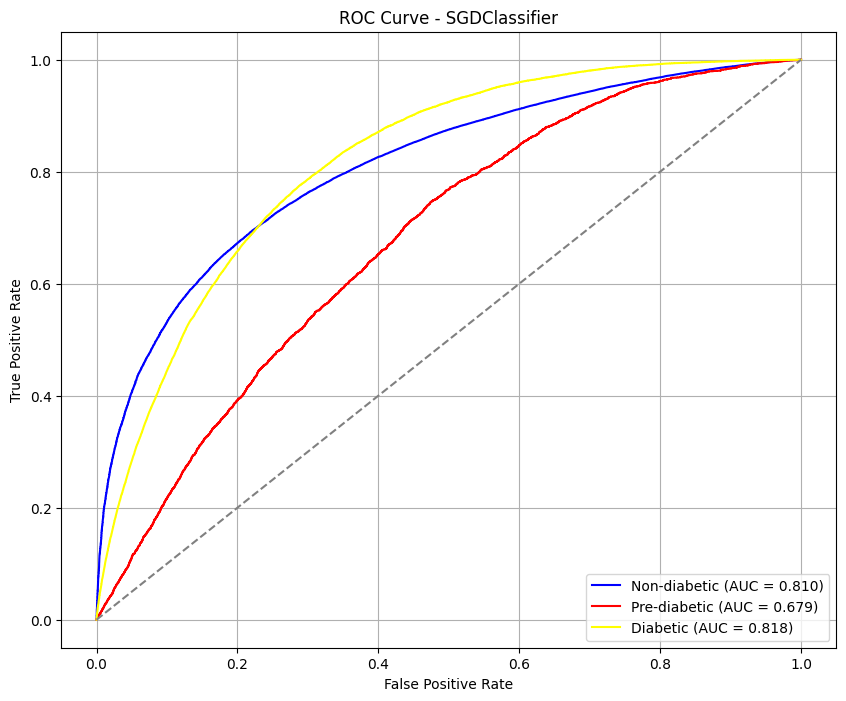

In [16]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=sgd_class_probabilities,
    model_name="SGDClassifier"
)

In [17]:
# Evaluate SGDClassifier model with cross-validation
sgd_model_cv_scores = sgd_model.cross_validate(X=X_train_normalized, y=y_train)
sgd_model_cv_scores

2025-09-16 21:05:07,872 - [src.models] - INFO - Cross-validation results:
2025-09-16 21:05:07,873 - [src.models] - INFO - Mean accuracy: 0.8402 (+/- 0.0013)


array([0.83996604, 0.8408218 , 0.84025838, 0.8390998 , 0.84097257])

### **3.2 Logistic Regression**

Logistic Regression is a classic and effective algorithm for classification problems, especially suitable for medical data because of its good interpretability. The model is configured with optimal parameters and logged into . `../logs/2_logistic_regression_with_original_data.log`

Strengths of Logistic Regression in the diabetes problem:

- Provides clear probability estimates for each class
- Coefficients are interpretable, helping to understand the relationship between features and targets
- Stable and less prone to overfitting with large datasets

In [18]:
# Initialize and configure Logistic Regression model
lr_model = DiabetesLogisticRegression(
    C=LR_C, 
    penalty=LR_PENALTY, 
    class_weight=LR_CLASS_WEIGHT,
    max_iter=LR_MAX_ITER, 
    solver=LR_SOLVER,
    random_state=RANDOM_STATE,
    verbose=LR_VERBOSE,
    n_jobs=N_JOBS,
    log_file=f"{LOG_DIR}/2_logistic_regression_with_original_data.log"
)

2025-09-16 21:05:07,895 - [src.models] - INFO - DiabetesLogisticRegression initialized with parameters:
2025-09-16 21:05:07,899 - [src.models] - INFO -   C: 1.0
2025-09-16 21:05:07,900 - [src.models] - INFO -   penalty: l2
2025-09-16 21:05:07,900 - [src.models] - INFO -   class_weight: None
2025-09-16 21:05:07,906 - [src.models] - INFO -   solver: saga
2025-09-16 21:05:07,907 - [src.models] - INFO -   max_iter: 100
2025-09-16 21:05:07,907 - [src.models] - INFO -   random_state: 42


In [19]:
# Get the model information
lr_model.get_model_info()

{'C': 1.0,
 'penalty': 'l2',
 'solver': 'saga',
 'max_iter': 100,
 'random_state': 42,
 'model_path': None}

In [20]:
# Train Logistic Regression model on normalized training data
lr_model.train(X=X_train_normalized, y=y_train)

2025-09-16 21:05:07,947 - [src.models] - INFO - Starting Logistic Regression model training...


2025-09-16 21:05:17,755 - [src.models] - INFO - Model training completed. Training samples: 630081


In [21]:
# Generate predictions
lr_y_pred = lr_model.predict(X=X_test_normalized)

2025-09-16 21:05:17,796 - [src.models] - INFO - Predictions made for 157521 samples


In [22]:
# Display the first 10 predictions to verify the output format
lr_y_pred[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [23]:
# Evaluate LogisticRegression model
lr_model_eval_results = lr_model.evaluate(y_true=y_test, y_pred=lr_y_pred)

2025-09-16 21:05:17,964 - [src.models] - INFO - Model Evaluation Results:
2025-09-16 21:05:17,964 - [src.models] - INFO - Accuracy: 0.8412
2025-09-16 21:05:17,965 - [src.models] - INFO - Precision: 0.4663
2025-09-16 21:05:17,966 - [src.models] - INFO - Recall: 0.3864
2025-09-16 21:05:17,966 - [src.models] - INFO - F1-Score: 0.3955
2025-09-16 21:05:18,024 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.98      0.91    131574
         1.0       0.00      0.00      0.00      3393
         2.0       0.54      0.18      0.27     22554

    accuracy                           0.84    157521
   macro avg       0.47      0.39      0.40    157521
weighted avg       0.79      0.84      0.80    157521

2025-09-16 21:05:18,091 - [src.models] - INFO - Confusion Matrix:
[[128365      0   3209]
 [  3107      0    286]
 [ 18412      0   4142]]


In [24]:
# Display model performance metrics
lr_model_eval_results

{'accuracy': 0.8412021254308949,
 'precision': 0.4662628456708222,
 'recall': 0.38641960544349435,
 'f1_score': 0.3955098679179389}

In [25]:
# Predict class probabilities
lr_class_probabilities = lr_model.predict_proba(X=X_test_normalized)

2025-09-16 21:05:18,150 - [src.models] - INFO - Probabilities predicted for 157521 samples


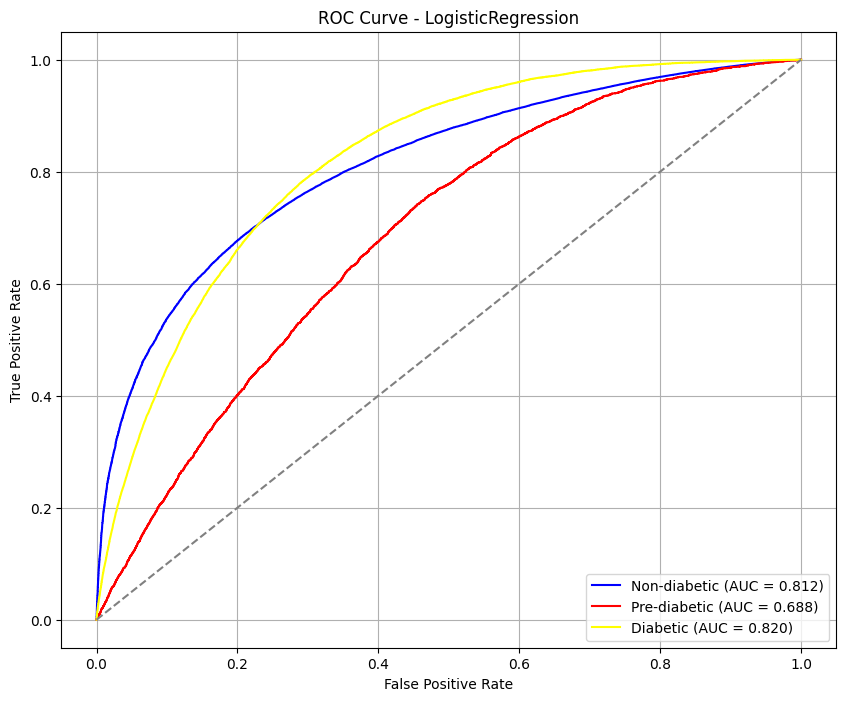

In [26]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=lr_class_probabilities,
    model_name="LogisticRegression"
)

In [27]:
# Evaluate Logistic Regression with cross-validation
lr_model_cv_scores = lr_model.cross_validate(X=X_train_normalized, y=y_train)
lr_model_cv_scores

2025-09-16 21:05:56,708 - [src.models] - INFO - Cross-validation results:
2025-09-16 21:05:56,710 - [src.models] - INFO - Mean accuracy: 0.8406 (+/- 0.0009)


array([0.83999778, 0.84049644, 0.84076625, 0.84036154, 0.84138522])

### **3.3 Naive Bayes**

Naive Bayes is a probabilistic algorithm based on Bayes theorem, suitable for features with conditional independence. The model is log-in and uses Gaussian variant suitable for continuous features such as BMI, MentHlth, PhysHlth. `../logs/2_naive_bayes_with_original_data.log`

Characteristics of Naive Bayes in this context:

- Training is rapid and memory-efficient
- Works well even with small training data
- Robust with noisy data and irrelevant features
- Provides probabilistic predictions useful for medical diagnosis

In [28]:
# Initialize and configure Gaussian Naive Bayes model
nb_model = DiabetesNaiveBayes(
    nb_type=NB_TYPE,
    var_smoothing=NB_VAR_SMOOTHING,
    binarize=NB_BINARIZE,
    alpha=NB_ALPHA,
    log_file=f"{LOG_DIR}/2_naive_bayes_with_original_data.log"
)

2025-09-16 21:05:56,724 - [src.models] - INFO - DiabetesNaiveBayes (Gaussian) initialized with parameters:
2025-09-16 21:05:56,729 - [src.models] - INFO -   nb_type: gaussian
2025-09-16 21:05:56,731 - [src.models] - INFO -   var_smoothing: 1e-09


In [29]:
# Get the model information
nb_model.get_model_info()

{'nb_type': 'gaussian',
 'var_smoothing': 1e-09,
 'model_path': None,
 'is_fitted': False}

In [30]:
# Train Naive Bayes model on normalized training data
nb_model.train(X=X_train_normalized, y=y_train)

2025-09-16 21:05:56,769 - [src.models] - INFO - Starting Gaussian Naive Bayes model training...
2025-09-16 21:05:57,050 - [src.models] - INFO - Model training completed. Training samples: 630081
2025-09-16 21:05:57,050 - [src.models] - INFO - Number of classes: 3
2025-09-16 21:05:57,051 - [src.models] - INFO - Classes: [0. 1. 2.]


In [31]:
# Generate predictions
nb_y_pred = nb_model.predict(X=X_test_normalized)

2025-09-16 21:05:57,131 - [src.models] - INFO - Predictions made for 157521 samples


In [32]:
# Display the first 10 predictions to verify the output format
nb_y_pred[:10]

array([0., 2., 0., 0., 2., 0., 0., 0., 0., 0.])

In [33]:
# Evaluate NaiveBayes model
nb_model_eval_results = nb_model.evaluate(y_true=y_test, y_pred=nb_y_pred)

2025-09-16 21:05:57,211 - [src.models] - INFO - Model Evaluation Results:
2025-09-16 21:05:57,212 - [src.models] - INFO - Accuracy: 0.7547
2025-09-16 21:05:57,212 - [src.models] - INFO - Precision: 0.4246
2025-09-16 21:05:57,213 - [src.models] - INFO - Recall: 0.4643
2025-09-16 21:05:57,214 - [src.models] - INFO - F1-Score: 0.4297
2025-09-16 21:05:57,270 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.80      0.85    131574
         1.0       0.04      0.01      0.02      3393
         2.0       0.33      0.58      0.42     22554

    accuracy                           0.75    157521
   macro avg       0.42      0.46      0.43    157521
weighted avg       0.80      0.75      0.77    157521

2025-09-16 21:05:57,330 - [src.models] - INFO - Confusion Matrix:
[[105833    735  25006]
 [  1939     40   1414]
 [  9320    225  13009]]


In [34]:
# Display model performance metrics
nb_model_eval_results

{'accuracy': 0.754705721776779,
 'precision': 0.42459321983465675,
 'recall': 0.46431449824099674,
 'f1_score': 0.429725694047517}

In [35]:
# Predict class probabilities
nb_class_probabilities = nb_model.predict_proba(X=X_test_normalized)

2025-09-16 21:05:57,457 - [src.models] - INFO - Probabilities predicted for 157521 samples


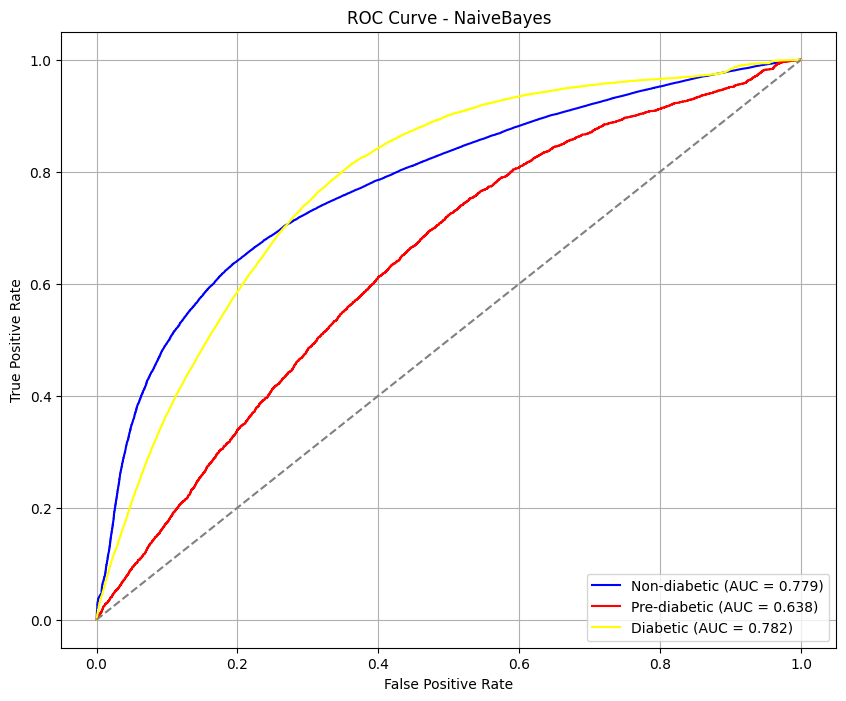

In [36]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=nb_class_probabilities,
    model_name="NaiveBayes"
)

In [37]:
# Evaluate Naive Bayes with cross-validation
nb_model_cv_scores = nb_model.cross_validate(X=X_train_normalized, y=y_train)
nb_model_cv_scores

2025-09-16 21:05:59,435 - [src.models] - INFO - Cross-validation results:
2025-09-16 21:05:59,436 - [src.models] - INFO - Mean accuracy: 0.7522 (+/- 0.0030)


array([0.75200171, 0.75406298, 0.74990477, 0.75159504, 0.7535313 ])

### **3.4 Random Forest**

Random Forest is an ensemble method that combines multiple decision trees, often giving high accuracy and less overfitting. The model is configured with the appropriate number of estimators and max_depth, log in . `../logs/2_random_forest_with_orignal_data.log`

Advantages of Random Forest for medical data:

- Handle different types of features (continuous, categorical) without much preprocessing
- Provide feature importance rankings, helping to understand which features are most important for prediction
- Robust with outliers (BMI has max=99 in the dataset)
- Automatically handle missing values and feature interactions

In [38]:
# Initialize and configure a Random Forest model
rf_model = DiabetesRandomForest(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    min_samples_split=RF_MIN_SAMPLES_SPLIT,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF,
    class_weight=RF_CLASS_WEIGHT,
    random_state=RANDOM_STATE,
    log_file=f"{LOG_DIR}/2_random_forest_with_orignal_data.log"
)

2025-09-16 21:05:59,448 - [src.models] - INFO - DiabetesRandomForest initialized with parameters:
2025-09-16 21:05:59,450 - [src.models] - INFO -   n_estimators: 100
2025-09-16 21:05:59,450 - [src.models] - INFO -   max_depth: 25
2025-09-16 21:05:59,451 - [src.models] - INFO -   min_samples_split: 5
2025-09-16 21:05:59,452 - [src.models] - INFO -   min_samples_leaf: 5
2025-09-16 21:05:59,453 - [src.models] - INFO -   max_features: sqrt
2025-09-16 21:05:59,453 - [src.models] - INFO -   class_weight: balanced
2025-09-16 21:05:59,454 - [src.models] - INFO -   random_state: 42


In [39]:
# Get the model information
rf_model.get_model_info()

{'n_estimators': 100,
 'max_depth': 25,
 'min_samples_split': 5,
 'min_samples_leaf': 5,
 'max_features': 'sqrt',
 'random_state': 42,
 'model_path': None}

In [40]:
# Train the Random Forest model on normalized training data
rf_model.train(X=X_train_normalized, y=y_train)

2025-09-16 21:05:59,479 - [src.models] - INFO - Starting Random Forest model training...
2025-09-16 21:07:00,219 - [src.models] - INFO - Model training completed. Training samples: 630081
2025-09-16 21:07:00,220 - [src.models] - INFO - Number of trees: 100


In [41]:
# Generate predictions
rf_y_pred = rf_model.predict(X=X_test_normalized)

2025-09-16 21:07:04,083 - [src.models] - INFO - Predictions made for 157521 samples


In [42]:
# Display the first 10 predictions to verify the output format
rf_y_pred[:10]

array([0., 2., 0., 0., 0., 0., 0., 0., 0., 0.])

In [43]:
# Evaluate Random Forest model
rf_model_eval_results = rf_model.evaluate(y_true=y_test, y_pred=rf_y_pred)

2025-09-16 21:07:04,151 - [src.models] - INFO - Model Evaluation Results:
2025-09-16 21:07:04,152 - [src.models] - INFO - Accuracy: 0.7547
2025-09-16 21:07:04,153 - [src.models] - INFO - Precision: 0.4380
2025-09-16 21:07:04,153 - [src.models] - INFO - Recall: 0.4953
2025-09-16 21:07:04,154 - [src.models] - INFO - F1-Score: 0.4458
2025-09-16 21:07:04,202 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.79      0.85    131574
         1.0       0.04      0.02      0.03      3393
         2.0       0.35      0.68      0.46     22554

    accuracy                           0.75    157521
   macro avg       0.44      0.50      0.45    157521
weighted avg       0.82      0.75      0.78    157521

2025-09-16 21:07:04,253 - [src.models] - INFO - Confusion Matrix:
[[103474   1223  26877]
 [  1667     65   1661]
 [  6905    306  15343]]


In [44]:
# Display model performance metrics
rf_model_eval_results

{'accuracy': 0.754705721776779,
 'precision': 0.4379746048657061,
 'recall': 0.4952891669376489,
 'f1_score': 0.4458111161545834}

In [45]:
# Predict class probabilities
rf_class_probabilities = rf_model.predict_proba(X=X_test_normalized)

2025-09-16 21:07:08,160 - [src.models] - INFO - Probabilities predicted for 157521 samples


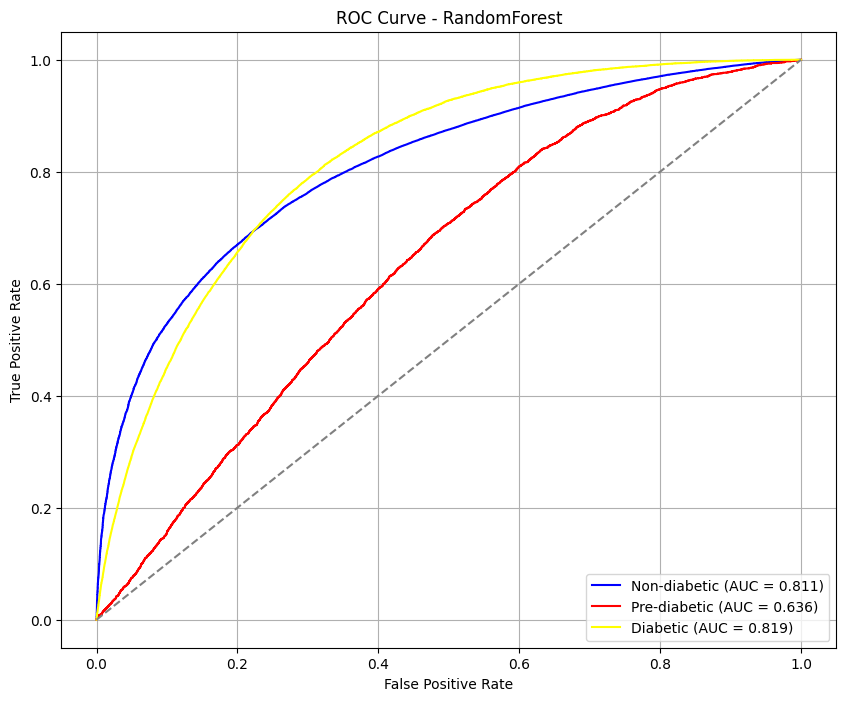

In [46]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=rf_class_probabilities,
    model_name="RandomForest"
)

In [47]:
# Evaluate Random Forest with cross-validation
rf_model_cv_scores = rf_model.cross_validate(X=X_train_normalized, y=y_train)
rf_model_cv_scores

2025-09-16 21:10:58,275 - [src.models] - INFO - Cross-validation results:
2025-09-16 21:10:58,276 - [src.models] - INFO - Mean accuracy: 0.7555 (+/- 0.0028)


array([0.75393003, 0.75507078, 0.75506285, 0.75554691, 0.75813389])

### **3.5 XGBoost**

XGBoost (eXtreme Gradient Boosting) is an advanced ensemble method that uses gradient boosting with optimized performance and regularization. It's particularly effective for structured/tabular data and has proven successful in many machine learning competitions. The model is configured with optimal hyperparameters and logged to `../logs/2_xgboost_with_orignal_data.log`.

Key advantages of XGBoost for diabetes prediction:

- **Superior Performance**: Often achieves higher accuracy than traditional algorithms through advanced boosting techniques
- **Built-in Regularization**: L1 and L2 regularization prevent overfitting, crucial for medical data
- **Feature Importance**: Provides detailed feature importance rankings to understand which health indicators matter most
- **Handles Missing Values**: Automatically learns the best direction to handle missing values during tree construction
- **Scalability**: Efficiently handles large datasets like BRFSS with optimized memory usage and parallel processing

The gradient boosting approach iteratively builds trees to correct previous errors, making it highly effective for complex patterns in medical data where interactions between features (like BMI, blood pressure, and age) are important for accurate diabetes prediction.


In [48]:
# Initialize and configure a XGBoost model
xgb_model = DiabetesXGBoostClassifier(
    n_estimators=XGB_N_ESTIMATORS,
    max_depth=XGB_MAX_DEPTH, 
    learning_rate=XGB_LEARNING_RATE, 
    subsample=XGB_SUBSAMPLE, 
    colsample_bytree=XGB_COLSAMPLE_BY_TREE, 
    log_file=f"{LOG_DIR}/2_xgboost_with_orignal_data.log"
)

2025-09-16 21:10:58,285 - [src.models] - INFO - DiabetesXGBoostClassifier initialized with parameters:
2025-09-16 21:10:58,285 - [src.models] - INFO -  n_estimators: 100
2025-09-16 21:10:58,287 - [src.models] - INFO -  max_depth: 6
2025-09-16 21:10:58,288 - [src.models] - INFO -  learning_rate: 0.1
2025-09-16 21:10:58,290 - [src.models] - INFO -  subsample: 1.0
2025-09-16 21:10:58,290 - [src.models] - INFO -  colsample_bytree: 1.0
2025-09-16 21:10:58,291 - [src.models] - INFO -  random_state: 42


In [49]:
# Get the model information
xgb_model.get_model_info()

{'n_estimators': 100,
 'max_depth': 6,
 'learning_rate': 0.1,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'random_state': 42,
 'model_path': None}

In [50]:
# Train the XGBoost model on normalized training data
xgb_model.train(X=X_train_normalized, y=y_train)

2025-09-16 21:10:58,309 - [src.models] - INFO - Starting XGBoost model training...
2025-09-16 21:11:10,664 - [src.models] - INFO - Model training completed. Training samples: 630081


In [51]:
# Generate predictions
xgb_y_pred = xgb_model.predict(X=X_test_normalized)

2025-09-16 21:11:10,969 - [src.models] - INFO - Predictions made for 157521 samples


In [52]:
# Display the first 10 predictions to verify the output format
xgb_y_pred[:10]

array([0, 2, 0, 0, 0, 0, 0, 0, 0, 0])

In [53]:
# Evaluate XGBoost model
xgb_model_eval_results = xgb_model.evaluate(y_true=y_test, y_pred=rf_y_pred)

2025-09-16 21:11:11,073 - [src.models] - INFO - Model Evaluation Results:
2025-09-16 21:11:11,074 - [src.models] - INFO - Accuracy: 0.7547
2025-09-16 21:11:11,075 - [src.models] - INFO - Precision: 0.4380
2025-09-16 21:11:11,075 - [src.models] - INFO - Recall: 0.4953
2025-09-16 21:11:11,076 - [src.models] - INFO - F1-Score: 0.4458
2025-09-16 21:11:11,138 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.79      0.85    131574
         1.0       0.04      0.02      0.03      3393
         2.0       0.35      0.68      0.46     22554

    accuracy                           0.75    157521
   macro avg       0.44      0.50      0.45    157521
weighted avg       0.82      0.75      0.78    157521

2025-09-16 21:11:11,203 - [src.models] - INFO - Confusion Matrix:
[[103474   1223  26877]
 [  1667     65   1661]
 [  6905    306  15343]]


In [54]:
# Display model performance metrics
xgb_model_eval_results

{'accuracy': 0.754705721776779,
 'precision': 0.4379746048657061,
 'recall': 0.4952891669376489,
 'f1_score': 0.4458111161545834}

In [55]:
# Predict class probabilities
xgb_class_probabilities = xgb_model.predict_proba(X=X_test_normalized)

2025-09-16 21:11:11,487 - [src.models] - INFO - Probabilities predicted for 157521 samples


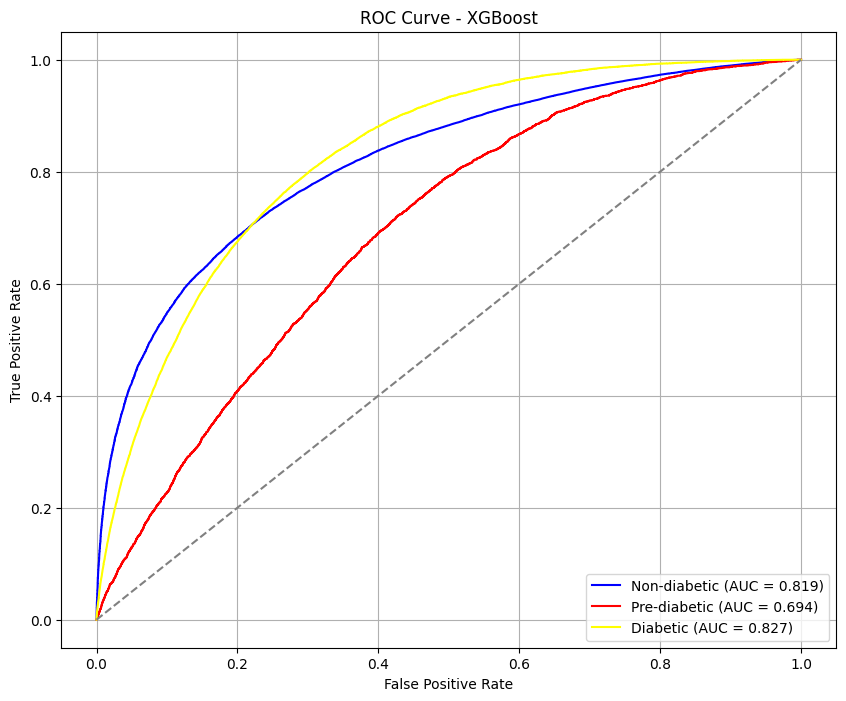

In [56]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=xgb_class_probabilities,
    model_name="XGBoost"
)

In [57]:
# Evaluate XGBoost with cross-validation
xgb_model_cv_scores = xgb_model.cross_validate(X=X_train_normalized, y=y_train)
xgb_model_cv_scores

2025-09-16 21:11:59,460 - [src.models] - INFO - Cross-validation results:
2025-09-16 21:11:59,462 - [src.models] - INFO - Mean accuracy: 0.8434 (+/- 0.0010)


array([0.84318782, 0.84384523, 0.84382142, 0.84253587, 0.84344845])

### **3.5 LightGBM**

LightGBM (Light Gradient Boosting Machine) is a fast, distributed, high-performance gradient boosting framework that uses tree-based learning algorithms. It's designed to be more efficient than XGBoost while maintaining comparable accuracy. The model is configured with appropriate parameters and logged to `../logs/2_lightgbm_with_orignal_data.log`.

Strengths of LightGBM for medical data analysis:

- **Speed and Memory Efficiency**: Significantly faster training and lower memory consumption compared to other boosting methods
- **High Accuracy**: Achieves excellent performance on tabular data through leaf-wise tree growth
- **Categorical Feature Support**: Native support for categorical features without requiring extensive preprocessing
- **Early Stopping**: Built-in early stopping prevents overfitting and reduces training time
- **Feature Importance**: Provides comprehensive feature importance analysis for medical interpretation

The leaf-wise tree growth strategy makes LightGBM particularly effective for datasets with complex feature interactions, such as the relationship between demographic factors, lifestyle choices, and health conditions in diabetes prediction. Its efficiency makes it suitable for production deployment in healthcare systems.


In [58]:
# Initialize and configure a LightGBM model
lgbm_model = DiabetesLightGBMClassifier(
    n_estimators=LGBM_N_ESTIMATORS, 
    max_depth=LGBM_MAX_DEPTH, 
    learning_rate=LGBM_LEARNING_RATE, 
    num_leaves=LGBM_NUM_LEAVES, 
    subsample=LGBM_SUBSAMPLE, 
    colsample_bytree=LGBM_COLSAMPLE_BY_TREE,  
    log_file=f"{LOG_DIR}/2_lightgbm_with_orignal_data.log"
)

2025-09-16 21:11:59,485 - [src.models] - INFO - DiabetesLightGBMClassifier initialized with parameters:
2025-09-16 21:11:59,486 - [src.models] - INFO -  n_estimators: 100
2025-09-16 21:11:59,488 - [src.models] - INFO -  max_depth: -1
2025-09-16 21:11:59,489 - [src.models] - INFO -  learning_rate: 0.1
2025-09-16 21:11:59,490 - [src.models] - INFO -  num_leaves: 31
2025-09-16 21:11:59,492 - [src.models] - INFO -  subsample: 1.0
2025-09-16 21:11:59,493 - [src.models] - INFO -  colsample_bytree: 1.0
2025-09-16 21:11:59,494 - [src.models] - INFO -  random_state: 42


In [59]:
# Get the model information
lgbm_model.get_model_info()

{'n_estimators': 100,
 'max_depth': -1,
 'learning_rate': 0.1,
 'num_leaves': 31,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'random_state': 42,
 'model_path': None}

In [60]:
# Train the LightGBM model on normalized training data
lgbm_model.train(X=X_train_normalized, y=y_train)

2025-09-16 21:11:59,520 - [src.models] - INFO - Starting LightGBM model training...


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052511 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 205
[LightGBM] [Info] Number of data points in the train set: 630081, number of used features: 20
[LightGBM] [Info] Start training from score -0.179990
[LightGBM] [Info] Start training from score -3.837987
[LightGBM] [Info] Start training from score -1.943619


2025-09-16 21:12:07,963 - [src.models] - INFO - Model training completed. Training samples: 630081


In [61]:
# Generate predictions
lgbm_y_pred = lgbm_model.predict(X=X_test_normalized)

2025-09-16 21:12:09,199 - [src.models] - INFO - Predictions made for 157521 samples


In [62]:
# Display the first 10 predictions to verify the output format
lgbm_y_pred[:10]

array([0., 2., 0., 0., 0., 0., 0., 0., 0., 0.])

In [63]:
# Evaluate LightGBM model
lgbm_model_eval_results = lgbm_model.evaluate(y_true=y_test, y_pred=rf_y_pred)

2025-09-16 21:12:09,302 - [src.models] - INFO - Model Evaluation Results:
2025-09-16 21:12:09,303 - [src.models] - INFO - Accuracy: 0.7547
2025-09-16 21:12:09,304 - [src.models] - INFO - Precision: 0.4380
2025-09-16 21:12:09,304 - [src.models] - INFO - Recall: 0.4953
2025-09-16 21:12:09,305 - [src.models] - INFO - F1-Score: 0.4458
2025-09-16 21:12:09,378 - [src.models] - INFO - Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.79      0.85    131574
         1.0       0.04      0.02      0.03      3393
         2.0       0.35      0.68      0.46     22554

    accuracy                           0.75    157521
   macro avg       0.44      0.50      0.45    157521
weighted avg       0.82      0.75      0.78    157521

2025-09-16 21:12:09,449 - [src.models] - INFO - Confusion Matrix:
[[103474   1223  26877]
 [  1667     65   1661]
 [  6905    306  15343]]


In [64]:
# Display model performance metrics
lgbm_model_eval_results

{'accuracy': 0.754705721776779,
 'precision': 0.4379746048657061,
 'recall': 0.4952891669376489,
 'f1_score': 0.4458111161545834}

In [65]:
# Predict class probabilities
lgbm_class_probabilities = lgbm_model.predict_proba(X=X_test_normalized)

2025-09-16 21:12:10,642 - [src.models] - INFO - Probabilities predicted for 157521 samples


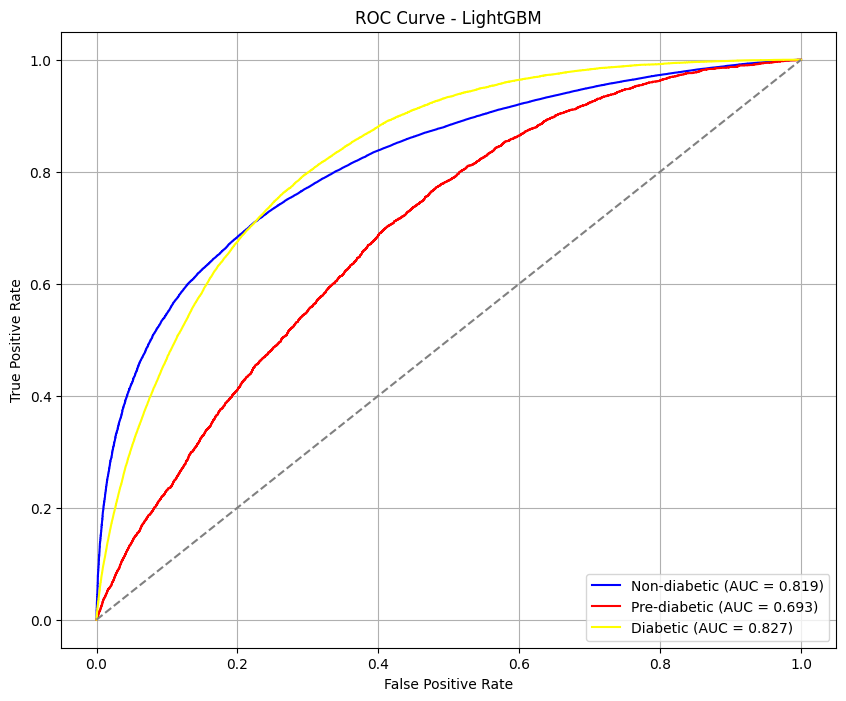

In [66]:
# Plot ROC and AUC
plot_roc_auc(
    y_true=y_test, 
    y_pred_proba=lgbm_class_probabilities,
    model_name="LightGBM"
)

In [67]:
# Evaluate LightGBM with cross-validation
lgbm_model_cv_scores = lgbm_model.cross_validate(X=X_train_normalized, y=y_train)
lgbm_model_cv_scores

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.041837 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 208
[LightGBM] [Info] Number of data points in the train set: 504064, number of used features: 20
[LightGBM] [Info] Start training from score -0.179990
[LightGBM] [Info] Start training from score -3.837985
[LightGBM] [Info] Start training from score -1.943623
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.069337 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 208
[LightGBM] [Info] Number of data points in the train set: 504065, number of used features: 20
[LightGBM] [Info] Start training from score -0.179992
[LightGBM] [Info] Start training from score -3.837987
[LightGBM] [Info] Start training from score -1.943612
[LightGBM] [Info] Auto-choosing ro

2025-09-16 21:12:54,409 - [src.models] - INFO - Cross-validation results:
2025-09-16 21:12:54,409 - [src.models] - INFO - Mean accuracy: 0.8435 (+/- 0.0009)


array([0.84317195, 0.84398013, 0.84379761, 0.84279774, 0.84384523])

## **4. Compare models**

This final section compares the performance of all four models on the same test set to determine which model is the best. This comparison includes:
**Metrics compared:**
- Accuracy: Overall correct prediction rate
- Precision: Accuracy of positive predictions
- Recall: Ability to detect positive cases
- F1-score: Harmonic mean of precision and recall

**Meaning in the medical context:**
- High recall is important to avoid missing diabetes cases (dangerous false negatives)
- High precision helps avoid over-diagnosis (costly false positives)
- Balanced F1-score for good overall performance

From the comparison results, we can determine:
- Which model is best suited for the diabetes prediction problem?
- Trade-offs between different metrics
- Recommendations for real-world deployments

This result will be the foundation for deciding whether to apply techniques such as feature engineering, data balancing, or hyperparameter tuning in later experiments.

In [68]:
# Compare all models' performance on the test set and display the comprehensive metrics table
models = {
    "SGDClassifier": sgd_model,
    "LogisticRegression": lr_model,
    "NaiveBayes": nb_model,
    "RandomForest": rf_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model
}
comparison_results = compare_models(
    models_dict=models, 
    X_test=X_test_normalized, 
    y_true=y_test
)

2025-09-16 21:12:54,454 - [src.models] - INFO - Predictions made for 157521 samples
2025-09-16 21:12:54,512 - [src.models] - INFO - Probabilities predicted for 157521 samples
2025-09-16 21:12:54,813 - [src.models] - INFO - Predictions made for 157521 samples
2025-09-16 21:12:54,845 - [src.models] - INFO - Probabilities predicted for 157521 samples
2025-09-16 21:12:55,182 - [src.models] - INFO - Predictions made for 157521 samples
2025-09-16 21:12:55,240 - [src.models] - INFO - Probabilities predicted for 157521 samples
2025-09-16 21:12:59,212 - [src.models] - INFO - Predictions made for 157521 samples
2025-09-16 21:13:02,695 - [src.models] - INFO - Probabilities predicted for 157521 samples
2025-09-16 21:13:03,054 - [src.models] - INFO - Predictions made for 157521 samples
2025-09-16 21:13:03,276 - [src.models] - INFO - Probabilities predicted for 157521 samples
2025-09-16 21:13:04,568 - [src.models] - INFO - Predictions made for 157521 samples
2025-09-16 21:13:05,766 - [src.models] - 

In [69]:
# Comparison results
comparison_results

,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,Precision-class0,Precision-class1,Precision-class2,Recall-class0,Recall-class1,Recall-class2,F1-class0,F1-class1,F1-class2
0,SGDClassifier,0.8400,0.7938,0.3921,0.4023,0.7693,0.8590,1.0000,0.5225,0.9703,0.0000,0.2061,0.9113,0.0000,0.2956
1,LogisticRegression,0.8412,0.7996,0.3864,0.3955,0.7733,0.8564,1.0000,0.5424,0.9756,0.0000,0.1836,0.9121,0.0000,0.2744
2,NaiveBayes,0.7547,0.4246,0.4643,0.4297,0.7332,0.9038,0.0400,0.3299,0.8044,0.0118,0.5768,0.8512,0.0182,0.4198
3,RandomForest,0.7547,0.4380,0.4953,0.4458,0.7552,0.9235,0.0408,0.3497,0.7864,0.0192,0.6803,0.8495,0.0261,0.4619
4,XGBoost,0.8433,0.8071,0.3883,0.3983,0.7801,0.8573,1.0000,0.5641,0.9775,0.0000,0.1874,0.9135,0.0000,0.2813
5,LightGBM,0.8433,0.8070,0.3880,0.3979,0.7797,0.8572,1.0000,0.5639,0.9776,0.0000,0.1864,0.9134,0.0000,0.2802


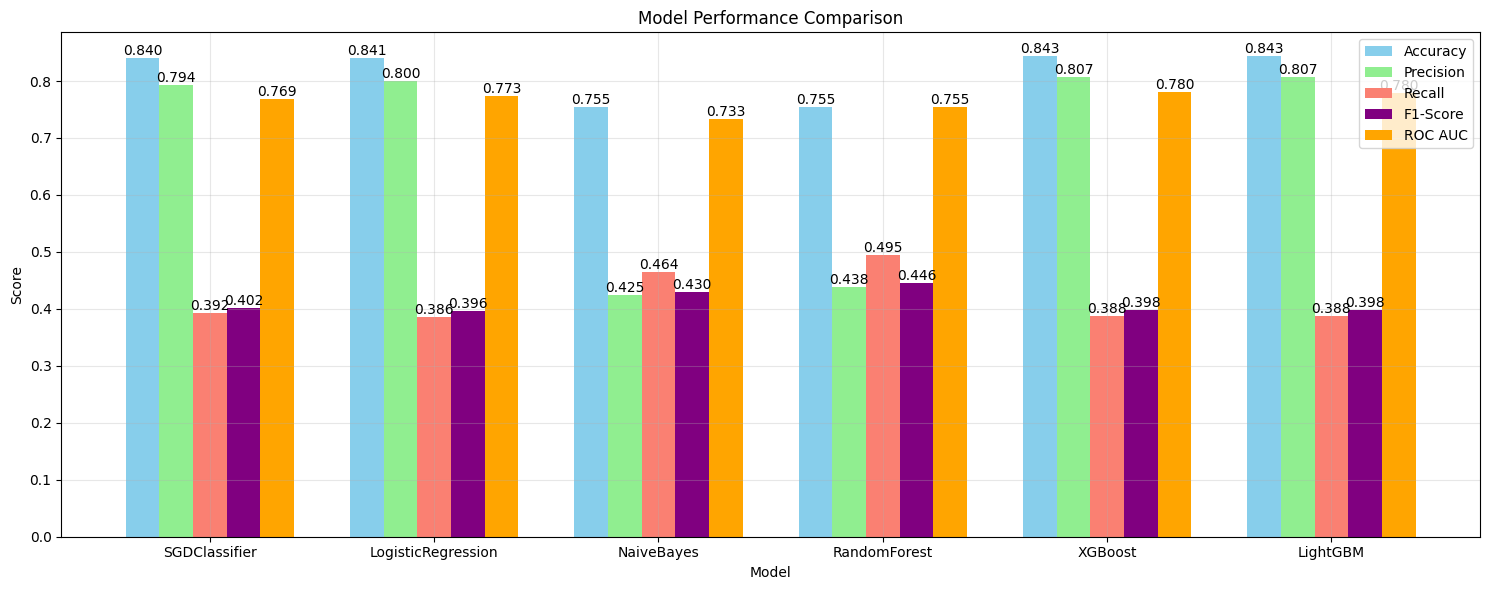

In [70]:
# Model comparison plot
plot_compare_models(comparison_df=comparison_results)